# Simple Image Segmentation Training Notebook

This notebook is a **simple training notebook** for students who are learning **classical image segmentation**.

## What students will learn
- how to download a dataset from Kaggle
- how to save it into Google Drive
- how to read images and masks
- how to segment objects using simple image processing
- how to compare predicted masks with true masks
- how to calculate basic segmentation metrics

## Method used
This notebook uses only **classical image processing**:
- grayscale conversion
- thresholding
- morphology
- connected components

It does **not** use deep learning.

## Dataset used
This notebook is prepared for a **small Kaggle segmentation dataset**.

You can use it in **Google Colab**.

The notebook:
1. mounts Google Drive
2. downloads the dataset from Kaggle
3. copies it into Google Drive
4. loads image-mask pairs
5. performs simple segmentation

## Step 1: Install package
If needed, install `kagglehub`.

In [18]:
# Uncomment this in Google Colab if needed
# !pip install -q kagglehub

## Step 2: Import libraries
These libraries are enough for a simple segmentation project.

In [17]:
import os
import re
import cv2
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import kagglehub

plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["image.cmap"] = "gray"

## Step 3: Mount Google Drive
This allows the files and results to stay saved.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 4: Download dataset from Kaggle
The dataset is downloaded first, then copied into Google Drive.

In [4]:
DOWNLOAD_DIR = Path(
    kagglehub.dataset_download("nizier193/leaf-segmentation-dataset-mk7")
)

print("Downloaded to:", DOWNLOAD_DIR)

DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/simple_segmentation_training")
DRIVE_PROJECT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_DIR = DRIVE_PROJECT_DIR / "dataset"

if not DATASET_DIR.exists():
    shutil.copytree(DOWNLOAD_DIR, DATASET_DIR)
    print("Copied dataset to Drive:", DATASET_DIR)
else:
    print("Dataset already exists in Drive:", DATASET_DIR)

100%|██████████| 22.7M/22.7M [00:02<00:00, 8.67MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/nizier193/leaf-segmentation-dataset-mk7/versions/1
Dataset already exists in Drive: /content/drive/MyDrive/simple_segmentation_training/dataset


## Step 5: Inspect the dataset folders
This helps students understand the dataset structure.

In [5]:
for root, dirs, files in os.walk(DATASET_DIR):
    level = root.replace(str(DATASET_DIR), "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{Path(root).name}/")
    for f in files[:3]:
        print(" " * 2 * (level + 1) + f)
    if level >= 2:
        continue

dataset/
  aug/
    masks/
      mask-205-0.jpg
      mask-172-1.jpg
      mask-261-0.jpg
    images/
      image-25-1.jpg
      image-138-1.jpg
      image-324-1.jpg


## Step 6: Find image and mask folders
This cell tries to automatically detect where images and masks are stored.

In [6]:
image_exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

all_dirs = [p for p in DATASET_DIR.rglob("*") if p.is_dir()]

def count_images(folder):
    return len([p for p in folder.glob("*") if p.suffix.lower() in image_exts])

image_candidates = []
mask_candidates = []

for d in all_dirs:
    name = d.name.lower()
    n_files = count_images(d)
    if n_files == 0:
        continue

    if any(k in name for k in ["image", "images", "img", "rgb"]):
        image_candidates.append((d, n_files))
    if any(k in name for k in ["mask", "masks", "label", "labels", "annotation", "annotations"]):
        mask_candidates.append((d, n_files))

print("Image candidates:")
for d, n in image_candidates[:10]:
    print("-", d, "|", n)

print("\nMask candidates:")
for d, n in mask_candidates[:10]:
    print("-", d, "|", n)

Image candidates:
- /content/drive/MyDrive/simple_segmentation_training/dataset/aug/images | 552

Mask candidates:
- /content/drive/MyDrive/simple_segmentation_training/dataset/aug/masks | 552


## Step 7: Select the folders
The notebook chooses the folder with the highest number of image files.

In [7]:
IMAGE_DIR = sorted(image_candidates, key=lambda x: x[1], reverse=True)[0][0]
MASK_DIR = sorted(mask_candidates, key=lambda x: x[1], reverse=True)[0][0]

print("IMAGE_DIR:", IMAGE_DIR)
print("MASK_DIR :", MASK_DIR)

IMAGE_DIR: /content/drive/MyDrive/simple_segmentation_training/dataset/aug/images
MASK_DIR : /content/drive/MyDrive/simple_segmentation_training/dataset/aug/masks


## Step 8: Helper functions
These functions make reading and visualization easier.

In [8]:
def read_image(path, size=(256, 256)):
    img = cv2.imread(str(path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    return img

def read_mask(path, size=(256, 256)):
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, size)
    _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    return mask

def show_many(images, titles, cols=3, size=(15, 8)):
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=size)
    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        if len(img.shape) == 2:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(img)
        plt.title(titles[i])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

def overlay_mask(image, mask, color=(255, 0, 0), alpha=0.35):
    out = image.copy()
    color_layer = np.zeros_like(image)
    color_layer[:, :] = color
    mask_bool = mask > 0
    out[mask_bool] = cv2.addWeighted(image[mask_bool], 1-alpha, color_layer[mask_bool], alpha, 0)
    return out

## Step 9: Build image-mask pairs
The filenames may start with different words like `image-` and `mask-`, so we match them using the numeric part.

In [9]:
def list_image_files(folder):
    return sorted([p for p in folder.rglob("*") if p.suffix.lower() in image_exts])

def extract_id(name):
    name = Path(name).stem.lower()
    m = re.search(r"(\d+-\d+)$", name)
    if m:
        return m.group(1)

    nums = re.findall(r"\d+", name)
    if len(nums) >= 2:
        return f"{nums[-2]}-{nums[-1]}"
    elif len(nums) == 1:
        return nums[0]
    return name

def build_pairs(image_dir, mask_dir):
    image_files = list_image_files(image_dir)
    mask_files = list_image_files(mask_dir)

    mask_map = {}
    for m in mask_files:
        mask_map[extract_id(m.name)] = m

    pairs = []
    for img_path in image_files:
        key = extract_id(img_path.name)
        if key in mask_map:
            pairs.append((img_path, mask_map[key]))

    return pairs

pairs = build_pairs(IMAGE_DIR, MASK_DIR)

print("Images found:", len(list_image_files(IMAGE_DIR)))
print("Masks found :", len(list_image_files(MASK_DIR)))
print("Pairs found :", len(pairs))

Images found: 552
Masks found : 552
Pairs found : 552


## Step 10: Preview one image and its mask
This is a simple way to verify that pairing is correct.

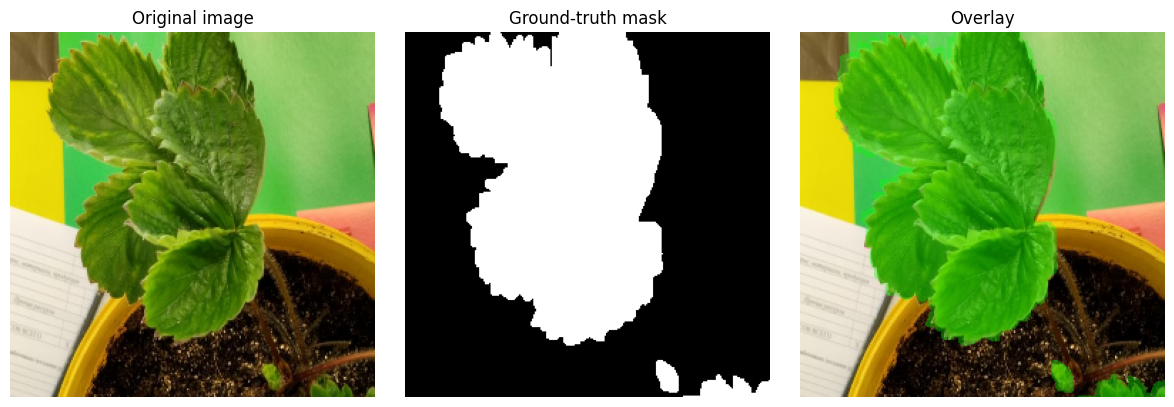

Image: image-0-0.jpg
Mask : mask-0-0.jpg


In [10]:
if len(pairs) == 0:
    raise ValueError("No image-mask pairs found. Check IMAGE_DIR and MASK_DIR.")

img_path, mask_path = pairs[0]

img = read_image(img_path)
gt = read_mask(mask_path)
over = overlay_mask(img, gt, color=(0, 255, 0))

show_many(
    [img, gt, over],
    ["Original image", "Ground-truth mask", "Overlay"],
    cols=3,
    size=(12, 4)
)

print("Image:", img_path.name)
print("Mask :", mask_path.name)

# Simple segmentation method

## Idea
We will use a very simple pipeline:
1. convert to grayscale
2. blur the image
3. apply thresholding
4. clean the mask using morphology
5. keep the largest object

This is a good beginner method.

In [19]:
def largest_component(binary):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    if num_labels <= 1:
        return binary

    areas = stats[1:, cv2.CC_STAT_AREA]
    largest_idx = 1 + np.argmax(areas)

    out = np.zeros_like(binary)
    out[labels == largest_idx] = 255
    return out

def segment_simple(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    _, mask = cv2.threshold(
        blur, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    kernel = np.ones((3, 3), np.uint8) # Changed kernel size from (5,5) to (3,3)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    mask = largest_component(mask)
    return gray, blur, mask

## Step 11: Apply simple segmentation to one image (with updated kernel size)

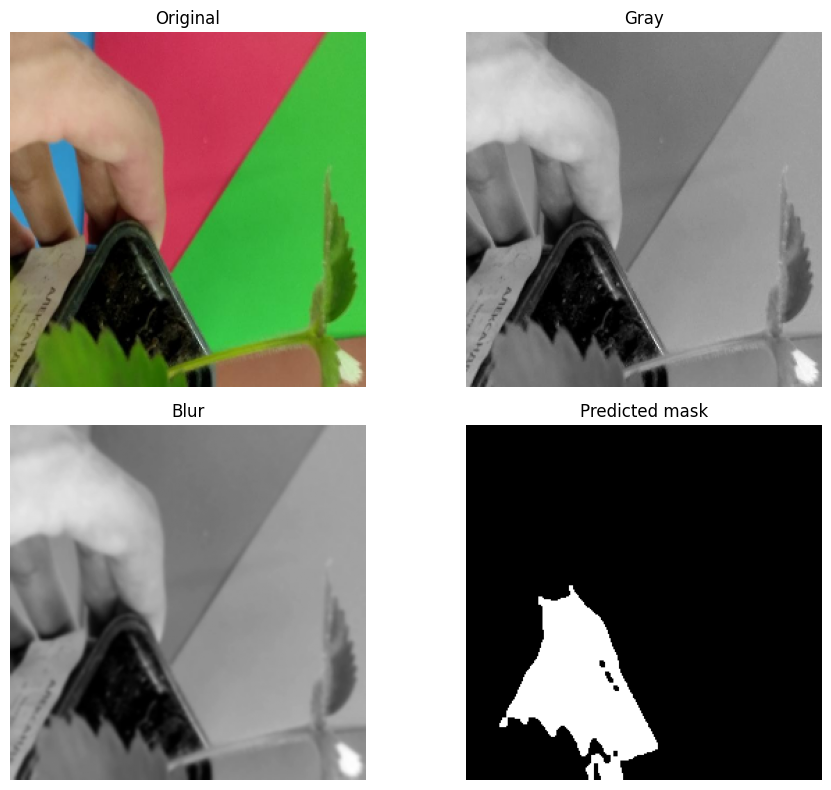

In [26]:
gray, blur, pred = segment_simple(img)

show_many(
    [img, gray, blur, pred],
    ["Original", "Gray", "Blur", "Predicted mask"],
    cols=2,
    size=(10, 8)
)

## Step 12: Compare true mask and predicted mask (with updated kernel size)

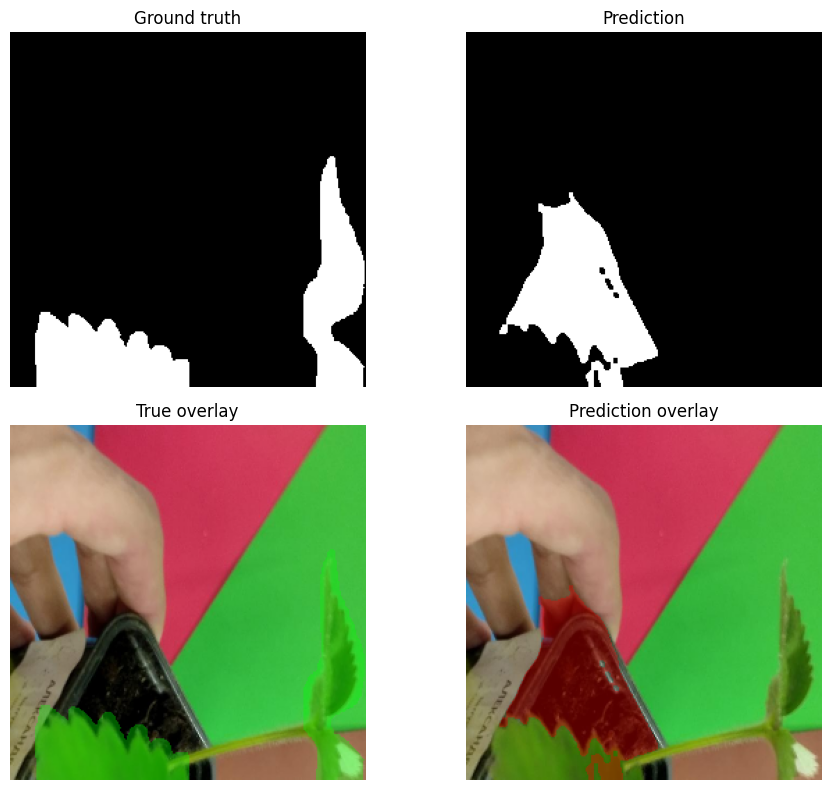

In [27]:
show_many(
    [gt, pred, overlay_mask(img, gt, color=(0, 255, 0)), overlay_mask(img, pred, color=(255, 0, 0))],
    ["Ground truth", "Prediction", "True overlay", "Prediction overlay"],
    cols=2,
    size=(10, 8)
)

## Step 13: Measure metrics for one image (with updated kernel size)

In [28]:
metrics_new_kernel = segmentation_metrics(gt, pred)

print("Metrics with kernel size (3,3):")
for k, v in metrics_new_kernel.items():
    print(f"{k:10s}: {v:.4f}")

print("\nOriginal metrics with kernel size (5,5):")
for k, v in metrics.items():
    print(f"{k:10s}: {v:.4f}")

Metrics with kernel size (3,3):
accuracy  : 0.7957
precision : 0.1754
recall    : 0.1484
f1_score  : 0.1608
iou       : 0.0874
dice      : 0.1608

Original metrics with kernel size (5,5):
accuracy  : 0.7066
precision : 0.5993
recall    : 0.8383
f1_score  : 0.6990
iou       : 0.5372
dice      : 0.6990


## Step 11: Apply simple segmentation to one image

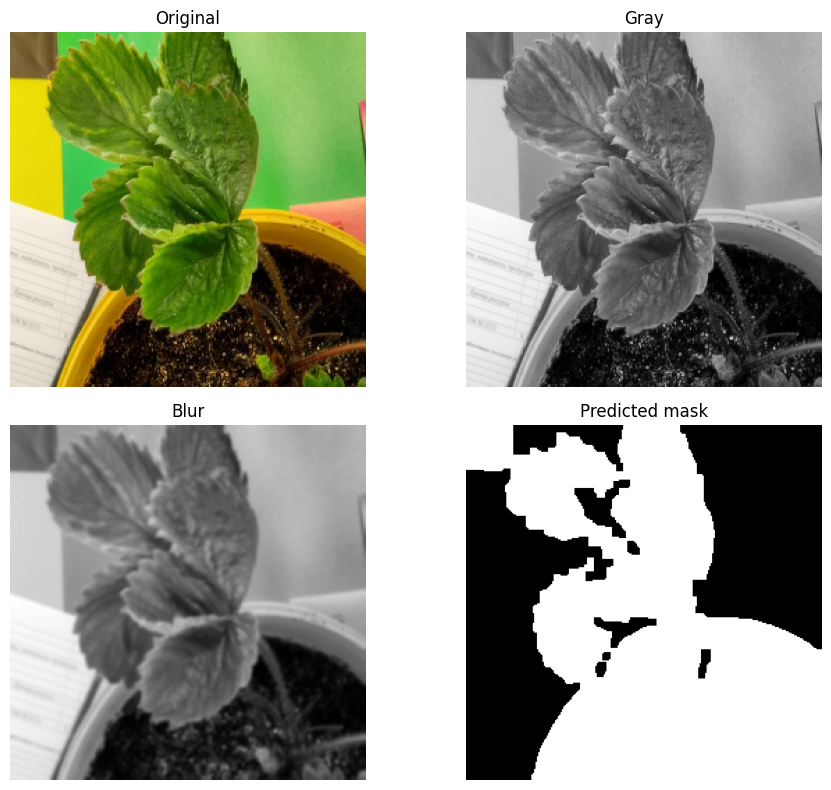

In [12]:
gray, blur, pred = segment_simple(img)

show_many(
    [img, gray, blur, pred],
    ["Original", "Gray", "Blur", "Predicted mask"],
    cols=2,
    size=(10, 8)
)

## Step 12: Compare true mask and predicted mask

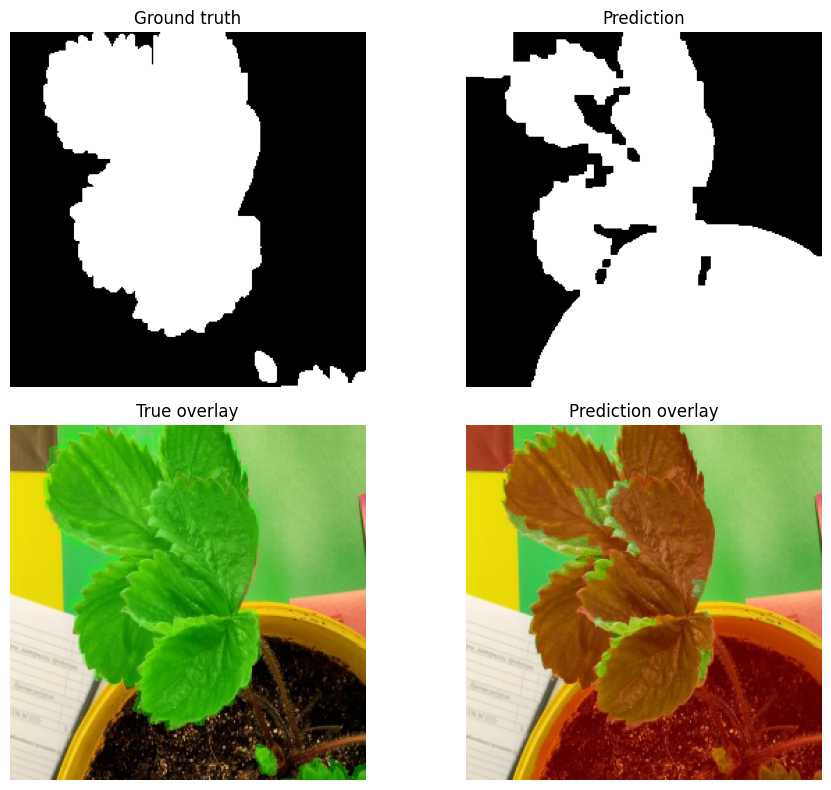

In [13]:
show_many(
    [gt, pred, overlay_mask(img, gt, color=(0, 255, 0)), overlay_mask(img, pred, color=(255, 0, 0))],
    ["Ground truth", "Prediction", "True overlay", "Prediction overlay"],
    cols=2,
    size=(10, 8)
)

# Metrics

We now calculate basic segmentation metrics.

## Metrics used
- Accuracy
- Precision
- Recall
- F1-score
- IoU
- Dice

In [14]:
def to_binary(mask):
    return (mask > 0).astype(np.uint8)

def segmentation_metrics(y_true, y_pred):
    y_true = to_binary(y_true).flatten()
    y_pred = to_binary(y_pred).flatten()

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (tp + tn) / (tp + tn + fp + fn + 1e-8)
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    iou = tp / (tp + fp + fn + 1e-8)
    dice = 2 * tp / (2 * tp + fp + fn + 1e-8)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "iou": iou,
        "dice": dice
    }

## Step 13: Measure metrics for one image

In [15]:
metrics = segmentation_metrics(gt, pred)

for k, v in metrics.items():
    print(f"{k:10s}: {v:.4f}")

accuracy  : 0.7066
precision : 0.5993
recall    : 0.8383
f1_score  : 0.6990
iou       : 0.5372
dice      : 0.6990


## Step 14: Evaluate several images
This helps students see average performance.

In [20]:
results = []

for img_path, mask_path in pairs[:50]:
    img = read_image(img_path)
    gt = read_mask(mask_path)
    _, _, pred = segment_simple(img)

    m = segmentation_metrics(gt, pred)
    row = {"image": img_path.name}
    row.update(m)
    results.append(row)

df = pd.DataFrame(results)
df.head()

,image,accuracy,precision,recall,f1_score,iou,dice
0,image-0-0.jpg,0.704224,0.597640,0.832908,0.695928,0.533657,0.695928
1,image-0-1.jpg,0.576187,0.720843,0.677920,0.698723,0.536952,0.698723
2,image-1-0.jpg,0.690277,0.471627,0.948406,0.629977,0.459829,0.629977
3,image-1-1.jpg,0.665176,0.413558,0.821243,0.550099,0.379405,0.550099
4,image-10-0.jpg,0.701157,0.708492,0.635800,0.670181,0.503964,0.670181


## Step 15: Average results

In [21]:
summary = df.mean(numeric_only=True)
summary

,0
accuracy,0.677737
precision,0.693261
recall,0.659716
f1_score,0.622351
iou,0.492584
dice,0.622351


## Step 16: Save results to Google Drive

In [22]:
RESULTS_DIR = DRIVE_PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

df.to_csv(RESULTS_DIR / "simple_segmentation_results.csv", index=False)

print("Saved to:", RESULTS_DIR / "simple_segmentation_results.csv")

Saved to: /content/drive/MyDrive/simple_segmentation_training/results/simple_segmentation_results.csv


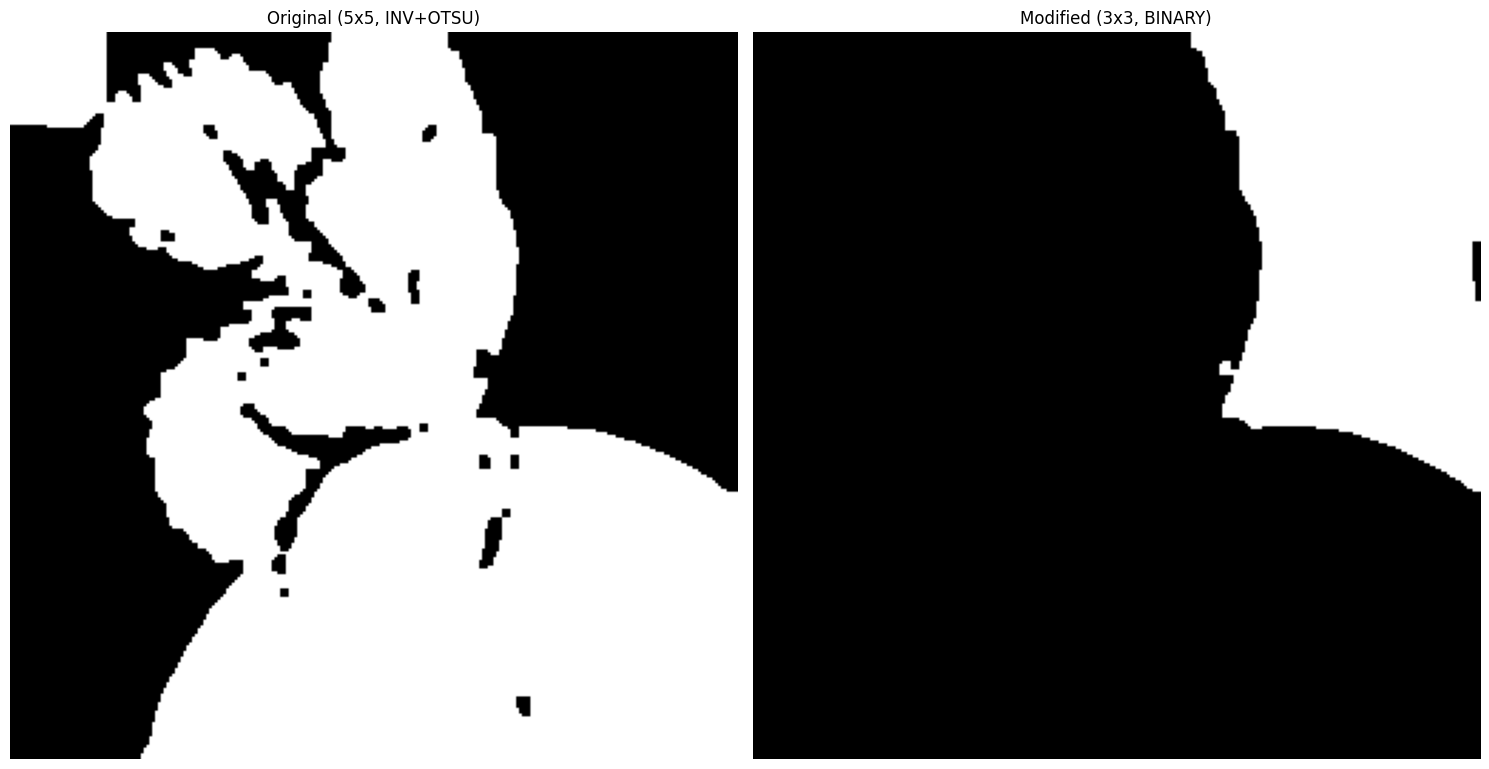

In [23]:
# TASK 1

def segment_modified(image, kernel_size=(3, 3), thresh_type=cv2.THRESH_BINARY):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    _, mask = cv2.threshold(blur, 127, 255, thresh_type)

    kernel = np.ones(kernel_size, np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    mask = largest_component(mask)
    return mask

img_test = read_image(pairs[0][0])
original_pred = segment_simple(img_test)[2]
modified_pred = segment_modified(img_test, kernel_size=(3, 3), thresh_type=cv2.THRESH_BINARY)

show_many(
    [original_pred, modified_pred],
    ["Original (5x5, INV+OTSU)", "Modified (3x3, BINARY)"],
    cols=2
)

In [24]:
# TASK 3

additional_results = []

for img_path, mask_path in pairs[50:60]:
    img = read_image(img_path)
    gt = read_mask(mask_path)
    _, _, pred = segment_simple(img)

    m = segmentation_metrics(gt, pred)
    m["image"] = img_path.name
    additional_results.append(m)

df_extra = pd.DataFrame(additional_results)
print("Средние метрики для 10 новых изображений:")
print(df_extra.mean(numeric_only=True))

Средние метрики для 10 новых изображений:
accuracy     0.739508
precision    0.632173
recall       0.535088
f1_score     0.543261
iou          0.432154
dice         0.543261
dtype: float64


--- 3 SUCCESS CASES ---


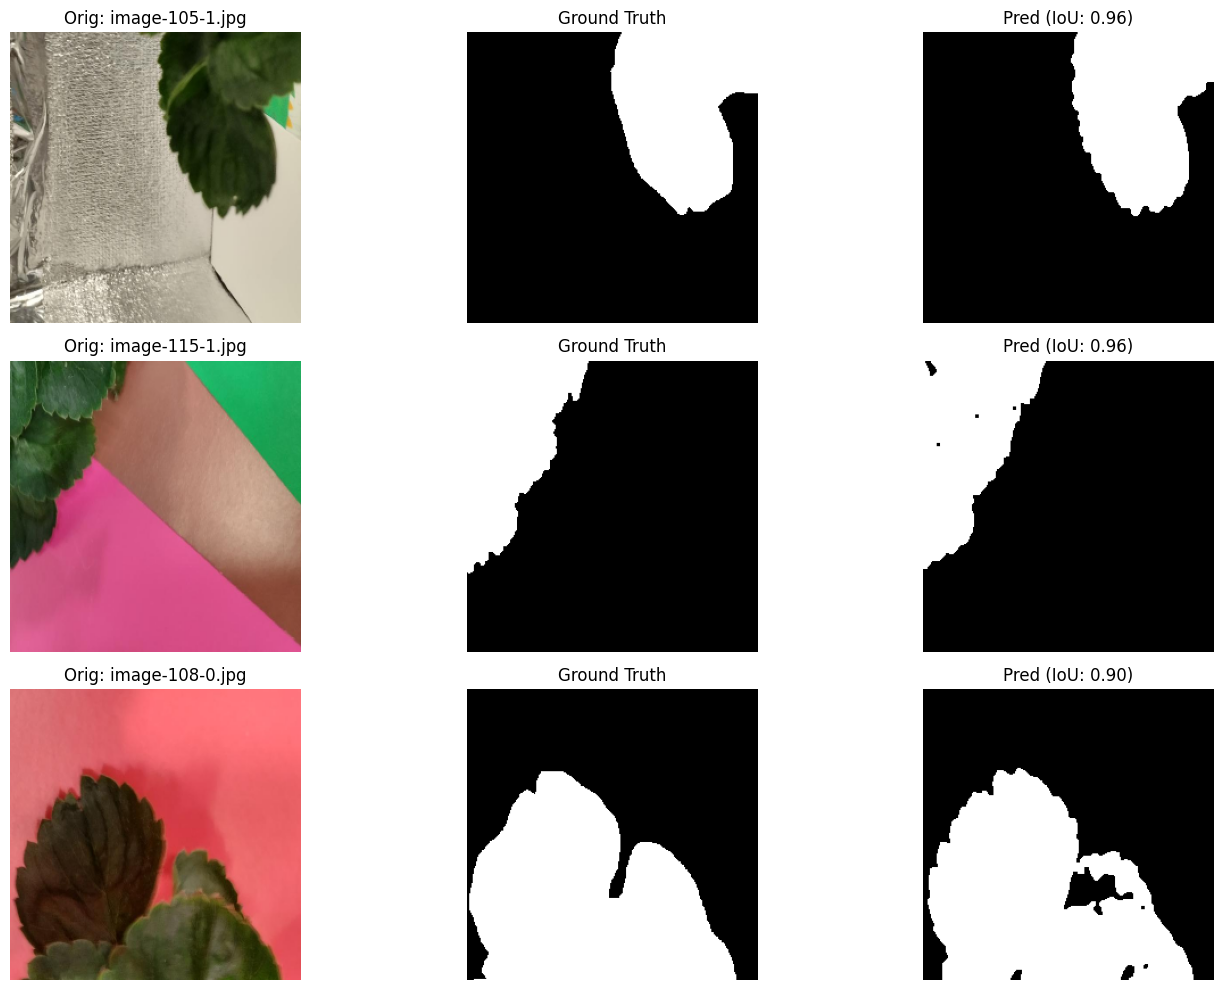

--- 3 FAILURE CASES ---


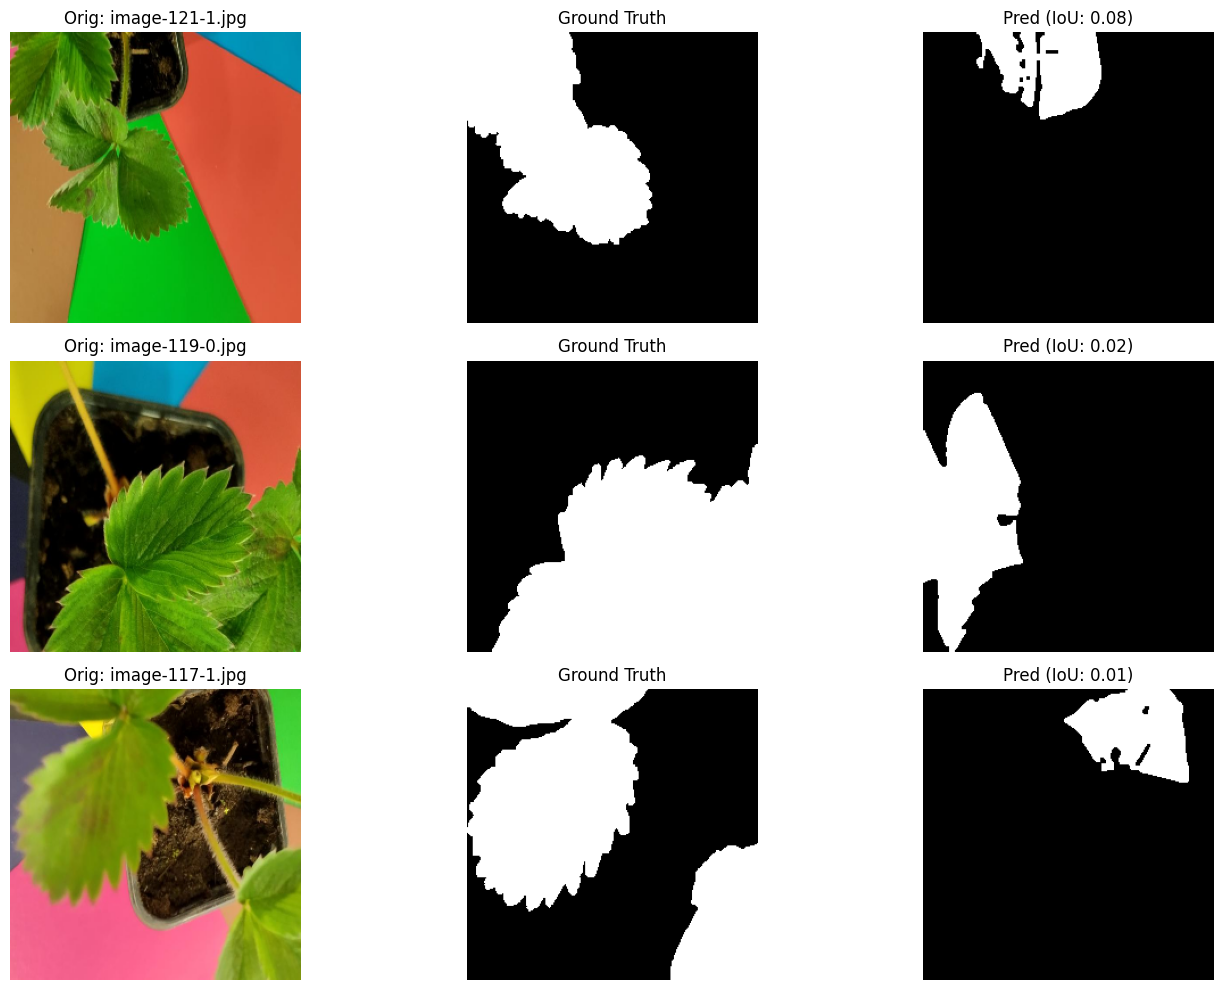

In [29]:
# TASK 4

sorted_df = df.sort_values(by="iou", ascending=False)

best_3 = sorted_df.head(3)
worst_3 = sorted_df.tail(3)

def display_cases(cases_df, title):
    print(f"--- {title} ---")
    imgs, titles = [], []
    for _, row in cases_df.iterrows():
        name = row['image']


        found_pair = next((p for p in pairs if p[0].name == name), None)

        if found_pair:
            img_p, mask_p = found_pair

            img = read_image(img_p)
            gt = read_mask(mask_p)
            _, _, pred = segment_simple(img)

            imgs.extend([img, gt, pred])
            titles.extend([f"Orig: {name}", "Ground Truth", f"Pred (IoU: {row['iou']:.2f})"])
        else:
            print(f"Warning: Could not find pair for image: {name}")

    show_many(imgs, titles, cols=3, size=(15, 10))

display_cases(best_3, "3 SUCCESS CASES")
display_cases(worst_3, "3 FAILURE CASES")

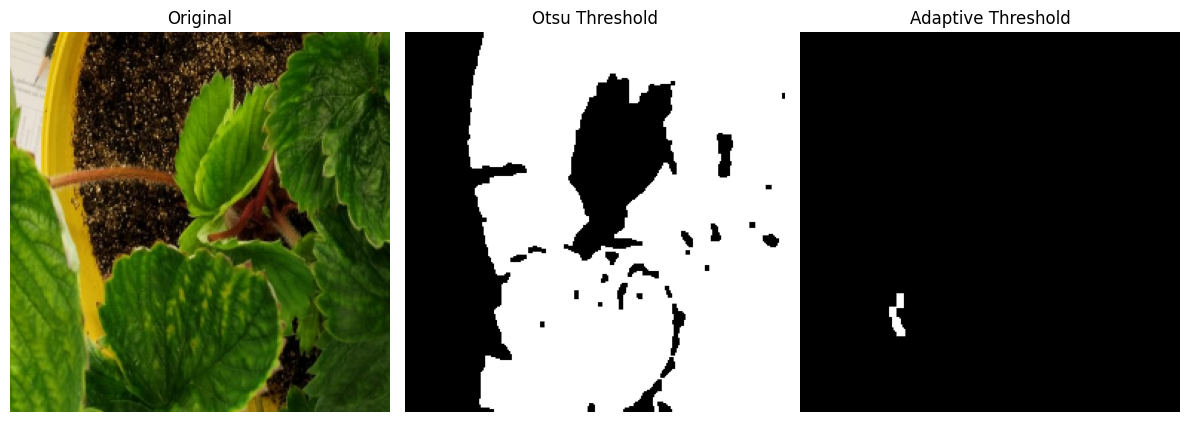

In [30]:
# TASK 5

def segment_adaptive(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    mask = cv2.adaptiveThreshold(
        blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 11, 2
    )

    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = largest_component(mask)
    return mask

img_test = read_image(pairs[1][0])
pred_otsu = segment_simple(img_test)[2]
pred_adaptive = segment_adaptive(img_test)

show_many(
    [img_test, pred_otsu, pred_adaptive],
    ["Original", "Otsu Threshold", "Adaptive Threshold"],
    cols=3,
    size=(12, 5)
)

# Training questions for students

1. Why do we convert the image to grayscale?
2. Why do we apply Gaussian blur?
3. What does Otsu thresholding do?
4. Why do we use opening and closing?
5. Why do we keep the largest component?
6. Which metric is more useful: IoU or Dice?
7. In which cases might this simple method fail?

# Small practice tasks

## Task 1
Change the kernel size from `(5,5)` to `(3,3)` and compare the result.

## Task 2
Try `cv2.THRESH_BINARY` instead of `cv2.THRESH_BINARY_INV`.

## Task 3
Test the method on 10 more images and compare the metrics.

## Task 4
Display 3 success cases and 3 failure cases.

## Task 5
Try adaptive thresholding and compare it with Otsu thresholding.

# Final note

This notebook is intentionally simple for training.

It is useful for:
- beginner image segmentation
- understanding masks
- learning thresholding
- learning morphology
- evaluating segmentation results